# 1. Image Recognition Task Based on CNN (MNIST)

# Environmental Testing and Data Loading

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
# Check if the PyTorch installation was successful
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
# Data preprocessing: Convert to Tensor, normalize
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.1307,), (0.3081,))
])
# Load MNIST data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)


PyTorch version: 2.8.0
GPU available: False


# Building a classic CNN network (simplified version of LeNet-5)

In [2]:
import torch.nn as nn
import torch.nn.functional as F
class LeNet(nn.Module):
   def __init__(self):
           super(LeNet, self).__init__()
           self.conv1 = nn.Conv2d(1,6,5) # Input channel 1, output channel 6, convolution kernel 5x5
           self.pool = nn.MaxPool2d(2,2) # Pooling layer, 2x2
           self.conv2 = nn.Conv2d(6, 16, 5)
           self.fc1 = nn.Linear(16*4*4,120) # Fully connected layer
           self.fc2 = nn.Linear(120, 84)
           self.fc3 = nn.Linear(84,10) # Output 10 categories
   def forward(self, x):
           x = self.pool(F.relu(self.conv1(x)))  # Conv1 + ReLU + Pool
           x = self.pool(F.relu(self.conv2(x)))  # Conv2 + ReLU + Pool
           x = x.view(-1, 16*4*4)                # Flatten                x = x.view(-1, 16*4*4)                # Flatten
           x = F.relu(self.fc1(x))               # FC1 + ReLU               x = F.relu(self.fc1(x))               # FC1 + ReLU
           x = F.relu(self.fc2(x))               # FC2 + ReLU               x = F.relu(self.fc2(x))               # FC2 + ReLU
           x = self.fc3(x) # Output                       x = self.fc3(x) # Output
           return x
net = LeNet()

# Model Training Preparation

In [3]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)  # Optimizer


# Training the model and documenting the process

In [4]:
num_epochs = 5
train_loss_list = []

for epoch in range(num_epochs):
   running_loss = 0.0
   for images, labels in train_loader:
       optimizer.zero_grad()
       outputs = net(images)
       loss = criterion(outputs, labels)
       loss.backward()
       optimizer.step()
       running_loss += loss.item()
   avg_loss = running_loss / len(train_loader)
   train_loss_list.append(avg_loss)
   print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")


Epoch 1, Loss: 0.2196
Epoch 2, Loss: 0.0665
Epoch 3, Loss: 0.0485
Epoch 4, Loss: 0.0378
Epoch 5, Loss: 0.0321


# Model Evaluation and Accuracy Calculation

In [5]:
correct = 0
total = 0
with torch.no_grad():
   for images, labels in test_loader:
       outputs = net(images)
       _, predicted = torch.max(outputs.data, 1)
       total += labels.size(0)
       correct += (predicted == labels).sum().item()

print(f"Accuracy on test set: {100 * correct / total:.2f}%")


Accuracy on test set: 98.82%


# Visualizing Training Loss

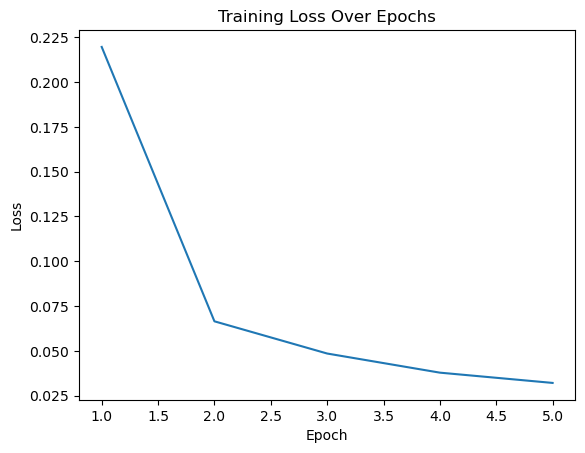

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), train_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

# Image Recognition Task Based on CNN (CIFAR-10)

# Data Loading and Enhancement

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

transform_train = transforms.Compose([
transforms.RandomHorizontalFlip(),
transforms.RandomCrop(32, padding=4),
transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)



# Visualizing CIFAR-10 images (4x4 16-grid)

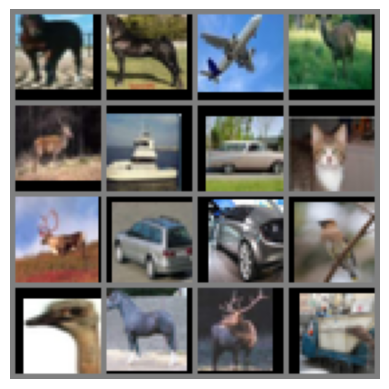

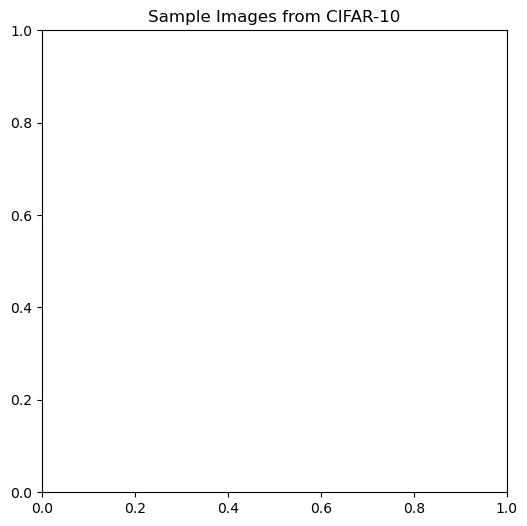

horse horse plane deer  deer  ship  car   cat   deer  car   car   bird  bird  horse deer  truck


In [5]:
import matplotlib.pyplot as plt
import numpy as np
# CIFAR-10 Category Labels
classes = ['plane', 'car', 'bird', 'cat',
          'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
# Get a batch of image data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Define the image inverse normalization function
def imshow(img):
   img = img / 2 + 0.5 # Reverse normalization
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.axis('off')
   # display image
   plt.figure(figsize=(6,6))
imshow(torchvision.utils.make_grid(images[:16], nrow=4))
plt.title('Sample Images from CIFAR-10')
plt.show()
# Print the corresponding label
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(16)))


# Build the CNN network (Mini VGG)

In [6]:
import torch.nn as nn

class MiniCNN(nn.Module):	
   def __init__(self):
           super(MiniCNN, self).__init__()
           self.conv_layer = nn.Sequential(
               nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
               nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
               nn.MaxPool2d(2, 2),  # 16x16
   
               nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
               nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
               nn.MaxPool2d(2, 2)   # 8x8
           )
           self.fc_layer = nn.Sequential(
               nn.Linear(64*8*8, 512), nn.ReLU(),
               nn.Linear(512, 10)
           )
   
   def forward(self, x):
           x = self.conv_layer(x)
           x = x.view(-1, 64*8*8)
           x = self.fc_layer(x)
           return x

net = MiniCNN()


# Defining the loss function and the optimizer

In [7]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)


# Training the Network

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

train_loss_list = []
for epoch in range (10): # Train for 10 rounds
   running_loss = 0.0
   for images, labels in trainloader:
           images, labels = images.to(device), labels.to(device)
           optimizer.zero_grad()
           outputs = net(images)
           loss = criterion(outputs, labels)
           loss.backward()
           optimizer.step()
           running_loss += loss.item()
   avg_loss = running_loss / len(trainloader)
   train_loss_list.append(avg_loss)
   print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')



Epoch 1, Loss: 1.5590
Epoch 2, Loss: 1.1412
Epoch 3, Loss: 0.9530
Epoch 4, Loss: 0.8419
Epoch 5, Loss: 0.7626
Epoch 6, Loss: 0.7107
Epoch 7, Loss: 0.6742
Epoch 8, Loss: 0.6310
Epoch 9, Loss: 0.6065
Epoch 10, Loss: 0.5814


# Testing the model accuracy

In [9]:
correct = 0
total = 0
net.eval()
with torch.no_grad():
   for images, labels in testloader:
           images, labels = images.to(device), labels.to(device)
           outputs = net(images)
           _, predicted = torch.max(outputs, 1)
           total += labels.size(0)
           correct += (predicted == labels).sum().item()
   print(f'Test Accuracy: {100 * correct / total:.2f}%')


Test Accuracy: 80.26%


# Visualizing Training Loss

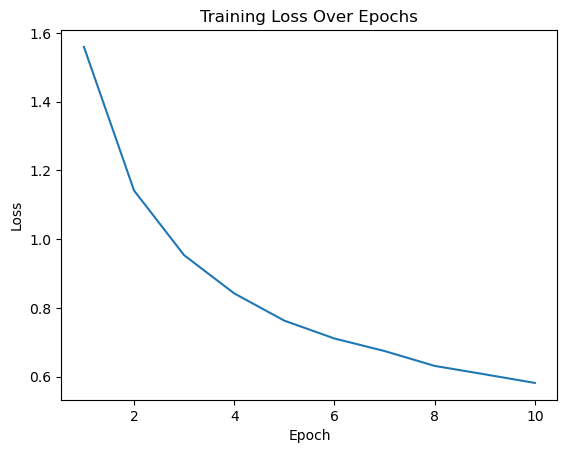

In [10]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(train_loss_list)+1), train_loss_list)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
